In [1]:
import pandas as pd

df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [2]:
drop_cols = [
    'EmployeeCount', 'Over18', 'StandardHours',
    'Education', 'JobInvolvement', 'JobLevel',
    'PercentSalaryHike', 'PerformanceRating',
    'StockOptionLevel'
]

df.drop(columns=drop_cols, inplace=True)

In [3]:
df['Attrition_OverTime'] = df['Attrition'] + "_" + df['OverTime']

In [4]:
total_employees = len(df)

attrition_rate = (df['Attrition'] == 'Yes').mean()

active_employees = (df['Attrition'] == 'No').sum()

avg_salary = df['MonthlyIncome'].mean()

avg_years = df['YearsAtCompany'].mean()

print("Total Employees:", total_employees)
print("Attrition Rate:", round(attrition_rate * 100, 2), "%")
print("Active Employees:", active_employees)
print("Average Salary:", round(avg_salary, 2))
print("Average Years:", round(avg_years, 2))

Total Employees: 1470
Attrition Rate: 16.12 %
Active Employees: 1233
Average Salary: 6502.93
Average Years: 7.01


In [5]:
df['Attrition'].value_counts(normalize=True) * 100

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64

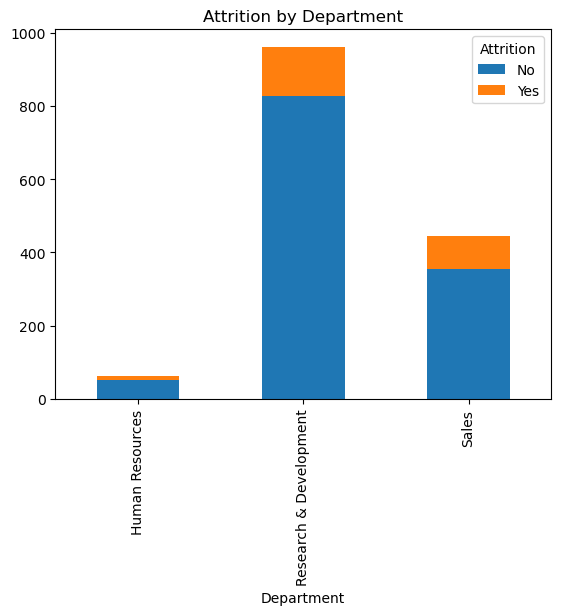

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

dept_attrition = pd.crosstab(df['Department'], df['Attrition'])

dept_attrition.plot(kind='bar', stacked=True)
plt.title("Attrition by Department")
plt.show()

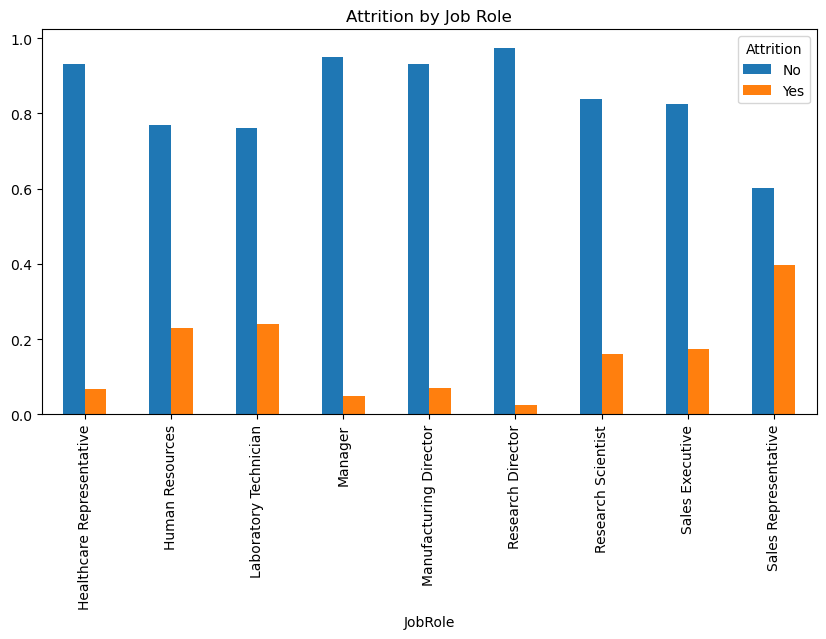

In [7]:
job_attrition = df.groupby('JobRole')['Attrition'].value_counts(normalize=True).unstack()

job_attrition.plot(kind='bar', figsize=(10,5))
plt.title("Attrition by Job Role")
plt.show()

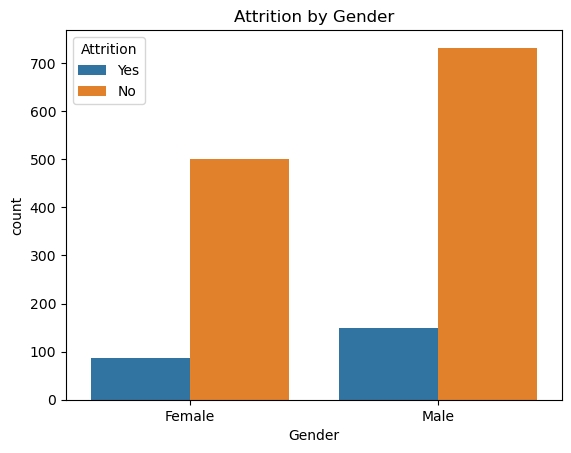

In [8]:
sns.countplot(data=df, x='Gender', hue='Attrition')
plt.title("Attrition by Gender")
plt.show()

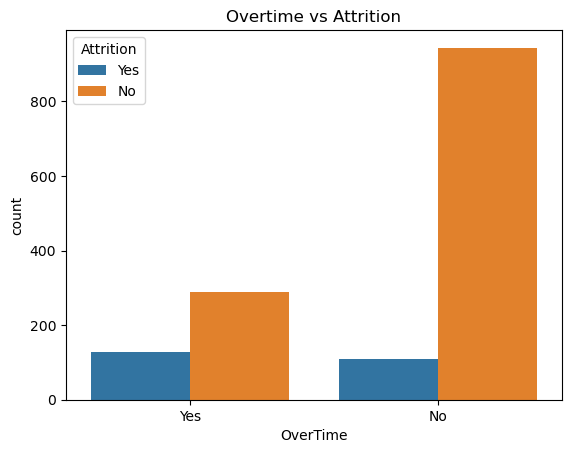

In [9]:
sns.countplot(data=df, x='OverTime', hue='Attrition')
plt.title("Overtime vs Attrition")
plt.show()

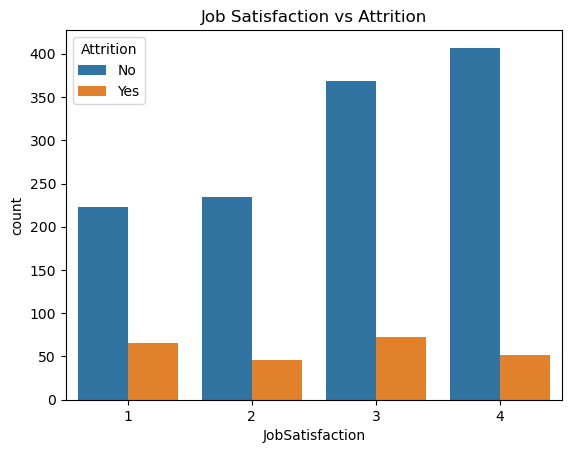

In [10]:
sns.countplot(data=df, x='JobSatisfaction', hue='Attrition')
plt.title("Job Satisfaction vs Attrition")
plt.show()

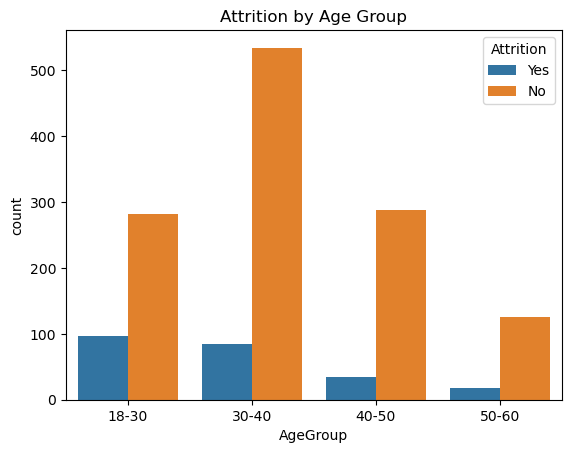

In [11]:
df['AgeGroup'] = pd.cut(df['Age'], bins=[18,30,40,50,60], labels=['18-30','30-40','40-50','50-60'])

sns.countplot(data=df, x='AgeGroup', hue='Attrition')
plt.title("Attrition by Age Group")
plt.show()

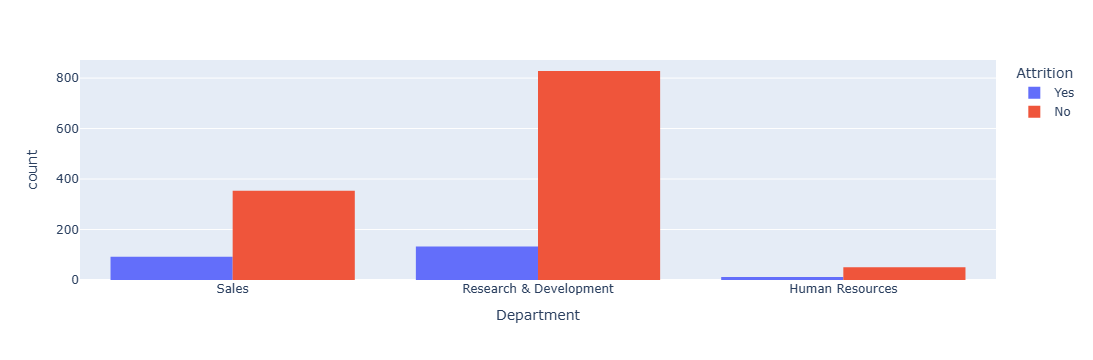

In [12]:
import plotly.express as px

fig = px.histogram(df, x="Department", color="Attrition", barmode="group")
fig.show()

In [13]:
import os
os.getcwd()

'C:\\Users\\Dell\\Downloads'

In [14]:
df.to_csv("cleaned_hr_data.csv", index=False)

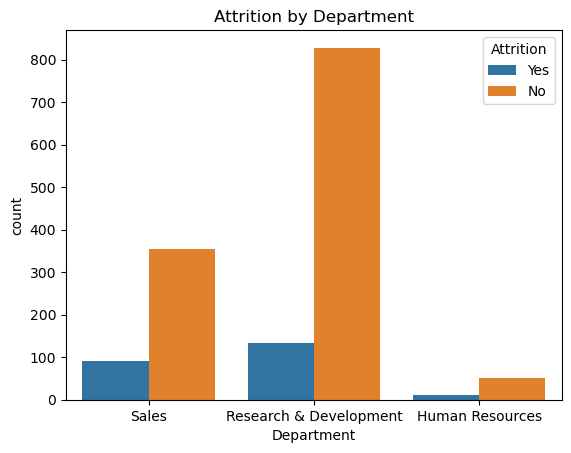

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(data=df, x='Department', hue='Attrition')

plt.title("Attrition by Department")

plt.savefig("attrition_by_department.png", dpi=300, bbox_inches='tight')  # SAVE FIRST
plt.show()

In [19]:
# Graph 1
sns.countplot(data=df, x='Gender', hue='Attrition')
plt.savefig("attrition_gender.png", dpi=300, bbox_inches='tight')
plt.clf()  # clear figure

# Graph 2
sns.countplot(data=df, x='OverTime', hue='Attrition')
plt.savefig("attrition_overtime.png", dpi=300, bbox_inches='tight')
plt.clf()

<Figure size 640x480 with 0 Axes>

In [20]:
import os

folder = "project_outputs"
os.makedirs(folder, exist_ok=True)

# Save data
df.to_csv(f"{folder}/cleaned_data.csv", index=False)

# Save graph
sns.countplot(data=df, x='Department', hue='Attrition')
plt.savefig(f"{folder}/dept_attrition.png", dpi=300, bbox_inches='tight')
plt.clf()

<Figure size 640x480 with 0 Axes>